From an Google Search 'Word2Vec' (https://www.google.com/search?q=word2vec&sca_esv=e755c4fcff4cb9a6&rlz=1C1ONGR_enUS1065US1065&sxsrf=APpeQnse_RvzfuT5h5oe8j2BE1mcGgX8LA%3A1785529232767&ei=kANtatmzLrmXruEP-OKzgQk&biw=2874.6865234375&bih=1066.833740234375&sclient=gws-wiz-serp&fbs=ABfTbFVyMZGZf1hfvX9uKjN_-G8c4u0nXx4bEIpwm1lnNH832VstEKsVDqPorK0Gahnm2no1YAFtlsByIZaJlK7yr6gIShz8_nfnRyCFKBFanfbilXpMs-cznwqr4eRh15jLYnTY1jneHErIL1s8ylJ677g0-Yzv9SeiVzusgosrLmIdC_Li_URL_fqqHo09-SPTQ8fS7ou1p27xw7ju_YWEy8MXRBbSOQ&aep=10&ntc=1&mstk=AUtExfDjGCbGLkqwvITjmZJS3lyGsQh-otF9QlZqdVr5gU5RMD2IR2k1L8GgtstNNOkW8V58BHVtijYOvkBDi7NBM5A_oMG-Zf0baGofEpssl-8tXTTBHYJ-zAyQf1SsQaucVv5i4H8Y9dLE6rxIA0H8BWHQDetvUAovqUuPvmgMDxNYH-jXqmnl36Mo1P1SpuyQKJJ34T4c3k2XTIGzOnTpSBNSxkUATZYU0fZjdRK4CXHm30zQHWnNHqBKrc5SRmytvIXI2UnV4_CWRQ&aioh=3&csuir=1&cs=0&sourceid=chrome&ccb=1&hl=en-US&atvm=1&mtid=NgRtau_2NaPrmLQPuaTfsAg&udm=50)



#### Install Libraries

In [ ]:
# Step 1: Install the Necessary Libraries

!pip install transformers datasets scikit-learn pandas matplotlib


In [ ]:
# Install torch separately; trying to do all of the installations at once caused  problems beforeL
!pip install torch

In [ ]:
# Check the version of torch:
import torch
print(torch.cuda.is_available())
print(torch.__version__)

#### Load a Pre-trained Medical BERT Model:

In [ ]:
# Step 2: Load a Pre-trained Medical BERT Model:

import torch
from transformers import AutoTokenizer, AutoModel

# Check that PyTorch sees your GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load the medical BERT tokenizer and model (BioBERT)
model_name = "dmis-lab/biobert-v1.1"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)

print("✅ Medical BERT model successfully loaded onto your GPU!")


#### Load/Create Datasets

##### Try this with 500 realistic records from Hugging Face, non-duplicated:

#### **Use a non-duplicated set of 500 cells.**

In [10]:
# These are the anomalies which will be injected:

anomalies_pool = [
    {"encounter_id": 2001, "specialty": "Neurology", "clinical_notes":
        "Patient presents to emergency department with sudden crushing retrosternal chest pain "
        "radiating to left jaw, accompanied by profuse sweating and dyspnea. Initial EKG reveals "
        "acute ST-segment elevation. Prepared for immediate cardiac catheterization."},
    {"encounter_id": 2002, "specialty": "Pediatrics", "clinical_notes":
        "An 84-year-old resident of an assisted living facility is evaluated for advanced cognitive "
        "decline, severe resting tremors in the right hand, and shuffling gait mechanics. Initiating "
        "trial of Carbidopa-Levodopa for Parkinsonian features."},
    {"encounter_id": 2003, "specialty": "Orthopedics", "clinical_notes":
        "Chief complaint centers on burning epigastric pain radiating to the chest, significantly "
        "worse postprandially and when recumbent. Patient reports passing dark, tarry stools for "
        "two days. Urgently scheduling an upper endoscopy (EGD)."},
    {"encounter_id": 2004, "specialty": "Cardiology", "clinical_notes":
        "A 4-year-old male child is brought in by his mother for a routine pediatric checkup and "
        "preschool clearance physical. Growth percentiles are tracking normally along the 70th "
        "line. Administered MMR and Varicella booster vaccines."},
    {"encounter_id": 2005, "specialty": "Gastroenterology", "clinical_notes":
        "The patient is a 22-year-old varsity athlete who experienced an inversion injury to the "
        "right ankle during a basketball match. Marked localized edema and ecchymosis noted. "
        "Radiograph indicates an acute non-displaced distal fibula fracture."},
    {"encounter_id": 2006, "specialty": "Neurology", "clinical_notes":
        "Patient presents with persistent watery diarrhea, severe lower abdominal cramping, and "
        "low-grade pyrexia following a recent course of Clindamycin. Stool assay is ordered to "
        "evaluate for Clostridioides difficile infection."},
    {"encounter_id": 2007, "specialty": "Pediatrics", "clinical_notes":
        "A 67-year-old postmenopausal female presents with a bone mineral density T-score of -2.8 "
        "via DEXA scan, indicating severe systemic osteoporosis. Initiating monthly oral "
        "Bisphosphonate therapy and calcium supplementation."},
    {"encounter_id": 2008, "specialty": "Cardiology", "clinical_notes":
        "Evaluation of a 45-year-old female complaining of a worsening throbbing unilateral "
        "headache accompanied by severe photophobia, phonophobia, and visual aura. Initiating "
        "prophylactic treatment with Topiramate."},
    {"encounter_id": 2009, "specialty": "Gastroenterology", "clinical_notes":
        "Patient displays an acute onset of left-sided facial droop, slurred speech, and pronator "
        "drift of the left upper extremity. Transferred emergently to the neuro-ICU for acute "
        "ischemic stroke evaluation and potential tPA administration."},
    {"encounter_id": 2010, "specialty": "Orthopedics", "clinical_notes":
        "Patient presents with progressive exertional dyspnea, orthopnea, and 3+ pitting edema of "
        "the lower extremities. Transthoracic echocardiogram demonstrates an ejection fraction "
        "reduced to 25%, consistent with congestive heart failure."}
]

In [11]:
import pandas as pd
from datasets import load_dataset

print("🔄 Streaming real unique medical records from Hugging Face...")
raw_dataset = load_dataset("NickyNicky/medical_mtsamples", split="train")
all_records = pd.DataFrame(raw_dataset)

# 1. Standardize columns and drop missing data
all_records = all_records.rename(columns={'medical_specialty': 'specialty', 'transcription': 'clinical_notes'})
all_records = all_records[['specialty', 'clinical_notes']].dropna()
all_records['specialty'] = all_records['specialty'].str.strip()
all_records['clinical_notes'] = all_records['clinical_notes'].str.strip()

# 2. REMOVED specialty filter to widen the pool for a larger dataset test
# (previously restricted to Cardiology|Orthopedics|Pediatrics|Neurology|Gastroenterology)
filtered_df = all_records.copy()

# 3. Drop all duplicate text records entirely to prevent artificial bias
filtered_df = filtered_df.drop_duplicates(subset=['clinical_notes'])

print(f"📋 Total unique records available across ALL specialties: {len(filtered_df)}")

# 4. Sample up to 5,000 unique records (or take all if fewer are available)
target_n = 5000
if len(filtered_df) >= target_n:
    df_real = filtered_df.sample(n=target_n, random_state=42).reset_index(drop=True)
else:
    print(f"⚠️ Only {len(filtered_df)} unique records available — using full pool instead of {target_n}.")
    df_real = filtered_df.copy().reset_index(drop=True)

df_real['encounter_id'] = range(1001, 1001 + len(df_real))

print(f"✅ Baseline established with {len(df_real)} completely UNIQUE medical records.")

# 5. Inject your 10 target anomalies (unchanged).  The anomaly pool was set up in the previous cell.


df = pd.concat([df_real, pd.DataFrame(anomalies_pool)], ignore_index=True)
df = df.sort_values(by="encounter_id").reset_index(drop=True)
print(f"📊 Global Dataset Finalized! Total records: {len(df)}")


🔄 Streaming real unique medical records from Hugging Face...
📋 Total unique records available across ALL specialties: 2357
⚠️ Only 2357 unique records available — using full pool instead of 5000.
✅ Baseline established with 2357 completely UNIQUE medical records.
📊 Global Dataset Finalized! Total records: 2367


#### Set up a pre-BERT Filter

In [12]:
# Pre-BERT Filter


import pandas as pd
import numpy as np

def run_pre_embedding_audit(dataframe):
    print("================================================================================")
    print("🛡️ RUNNING PRE-EMBEDDING DEFENSE FILTERS")
    print("================================================================================")

    # Create copies to prevent modifying the original data securely
    working_df = dataframe.copy()

    # Initialize lists to hold our filtered-out queues
    queue_a_insufficient = []
    queue_b_incomplete = []
    queue_pass_to_ml = []

    for index, row in working_df.iterrows():
        notes = str(row['clinical_notes']).strip()
        word_count = len(notes.split())
        char_count = len(notes)

        # ----------------------------------------------------------------------
        # LAYER 1: Word Count & Absolute Character Gatekeeper
        # ----------------------------------------------------------------------
        if char_count < 20 or word_count < 15:
            queue_a_insufficient.append({
                'encounter_id': row['encounter_id'],
                'specialty': row['specialty'],
                'issue': f"Severe Under-Documentation (Words: {word_count}, Chars: {char_count})",
                'text_snippet': notes[:80]
            })
            continue

        # ----------------------------------------------------------------------
        # LAYER 2: Sentence Incompleteness Parser
        # ----------------------------------------------------------------------
        last_char = notes[-1] if len(notes) > 0 else ""
        if last_char not in ['.', '!', '?']:
            queue_b_incomplete.append({
                'encounter_id': row['encounter_id'],
                'specialty': row['specialty'],
                'issue': f"Mid-Sentence Save Drop (Terminal character: '{last_char}')",
                'text_snippet': notes[-80:]
            })
            continue

        # If it passes both defense shields, it is safe to send to BioBERT
        queue_pass_to_ml.append(row)

    # Convert our results back into clean DataFrames for down-stream processing
    df_queue_a = pd.DataFrame(queue_a_insufficient)
    df_queue_b = pd.DataFrame(queue_b_incomplete)
    df_clean_ml = pd.DataFrame(queue_pass_to_ml).reset_index(drop=True)

    # Print out our audit discovery logs
    print(f"✅ Filter Complete! Clean records passed to ML Pipeline: {len(df_clean_ml)}")
    print(f"📥 ROUTED TO [QUEUE A - UNDER-DOCUMENTATION FILTERS]: {len(df_queue_a)}")
    print(f"📥 ROUTED TO [QUEUE B - MID-SENTENCE DROP FILTERS]   : {len(df_queue_b)}\n")

    # FIX: Loop through the raw dictionary list instead of the DataFrame columns
    if len(queue_a_insufficient) > 0:
        print("⚠️ SAMPLE OF BLANK / SEVERELY UNDER-DOCUMENTED RECORDS FOUND:")
        for item in queue_a_insufficient[:3]:
            print(f"  • ID: {item['encounter_id']} | Label: {item['specialty']} | Reason: {item['issue']}")
            print(f"    Text: \"{item['text_snippet']}\"")
        print()

    if len(queue_b_incomplete) > 0:
        print("⚠️ SAMPLE OF TRANSCRIPTION SAVES HALTED MID-SENTENCE:")
        for item in queue_b_incomplete[:3]:
            print(f"  • ID: {item['encounter_id']} | Label: {item['specialty']} | Reason: {item['issue']}")
            print(f"    Trailing End: \"...{item['text_snippet']}\"")
        print("================================================================================\n")

    return df_clean_ml, df_queue_a, df_queue_b

# Execute the pre-filters on your current main dataframe
df_clean, queue_a, queue_b = run_pre_embedding_audit(df)



🛡️ RUNNING PRE-EMBEDDING DEFENSE FILTERS
✅ Filter Complete! Clean records passed to ML Pipeline: 2113
📥 ROUTED TO [QUEUE A - UNDER-DOCUMENTATION FILTERS]: 24
📥 ROUTED TO [QUEUE B - MID-SENTENCE DROP FILTERS]   : 230

⚠️ SAMPLE OF BLANK / SEVERELY UNDER-DOCUMENTED RECORDS FOUND:
  • ID: 1025 | Label: Urology | Reason: Severe Under-Documentation (Words: 2, Chars: 17)
    Text: "CHIEF COMPLAINT:,"
  • ID: 1141 | Label: Urology | Reason: Severe Under-Documentation (Words: 10, Chars: 112)
    Text: "PREOPERATIVE DIAGNOSES:,1.  Recurrent bladder tumor.,2.  History of bladder carc"
  • ID: 1303 | Label: Surgery | Reason: Severe Under-Documentation (Words: 7, Chars: 62)
    Text: "PREOPERATIVE DIAGNOSIS:  ,1.  Right carpal tunnel syndrome.,2."

⚠️ SAMPLE OF TRANSCRIPTION SAVES HALTED MID-SENTENCE:
  • ID: 1005 | Label: Cardiovascular / Pulmonary | Reason: Mid-Sentence Save Drop (Terminal character: ',')
    Trailing End: "...hnically limited and hence subtle abnormalities could be missed from 

#### List records caught by the pre-embedding audit filters.

In [13]:
print("==================================================")
print("📥 RECORDS CAUGHT BY PRE-EMBEDDING AUDIT FILTERS")
print("==================================================")

# 1. Print out the Under-Documentation Filter captures (Queue A)
print(f"⚠️ QUEUE A: Insufficient Text / Blank Records ({len(queue_a)} total)")
if len(queue_a) > 0:
    for _, item in queue_a.iterrows():
        print(f"  • ID: {item['encounter_id']} | Specialty: {item['specialty']}")
else:
    print("  No records caught.")

print("\n" + "-"*50 + "\n")

# 2. Print out the Mid-Sentence Save Drop captures (Queue B)
print(f"⚠️ QUEUE B: Mid-Sentence Save Drops ({len(queue_b)} total)")
if len(queue_b) > 0:
    for _, item in queue_b.iterrows():
        print(f"  • ID: {item['encounter_id']} | Specialty: {item['specialty']}")
else:
    print("  No records caught.")
print("==================================================")

📥 RECORDS CAUGHT BY PRE-EMBEDDING AUDIT FILTERS
⚠️ QUEUE A: Insufficient Text / Blank Records (24 total)
  • ID: 1025 | Specialty: Urology
  • ID: 1141 | Specialty: Urology
  • ID: 1303 | Specialty: Surgery
  • ID: 1561 | Specialty: Surgery
  • ID: 1587 | Specialty: Surgery
  • ID: 1590 | Specialty: Surgery
  • ID: 1711 | Specialty: Surgery
  • ID: 1787 | Specialty: Surgery
  • ID: 2239 | Specialty: SOAP / Chart / Progress Notes
  • ID: 2362 | Specialty: Radiology
  • ID: 2365 | Specialty: Radiology
  • ID: 2585 | Specialty: Psychiatry / Psychology
  • ID: 2700 | Specialty: Pain Management
  • ID: 2706 | Specialty: Pain Management
  • ID: 2708 | Specialty: Pain Management
  • ID: 2719 | Specialty: Pain Management
  • ID: 2720 | Specialty: Pain Management
  • ID: 2746 | Specialty: Orthopedic
  • ID: 2748 | Specialty: Orthopedic
  • ID: 2763 | Specialty: Orthopedic
  • ID: 2778 | Specialty: Orthopedic
  • ID: 3030 | Specialty: General Medicine
  • ID: 3289 | Specialty: Consult - History 

#### Process Acroymns before Running BERT on the Data

In [14]:
import re

def normalize_clinical_acronyms(dataframe):
    print("================================================================================")
    print("🧠 RUNNING CLINICAL ACRONYM NORMALIZATION LAYER")
    print("================================================================================")

    working_df = dataframe.copy()

    # Dictionary mapping problematic shorthand acronyms to their full clear text descriptions
    acronym_dictionary = {
        r'\bAODM\b': 'Adult-Onset Diabetes Mellitus',
        r'\bHCT\b': 'Head Computed Tomography',
        r'\bERCP\b': 'Endoscopic Retrograde Cholangiopancreatography',
        r'\bEGD\b': 'Esophagogastroduodenoscopy',
        r'\bEEG\b': 'Electroencephalogram',
        r'\bMRI\b': 'Magnetic Resonance Imaging',
        r'\bCAD\b': 'Coronary Artery Disease',
        r'\bEKG\b': 'Electrocardiogram',
        r'\bBP\b': 'Blood Pressure'
    }

    transformation_counter = 0

    # Apply regex lookups across the clean notes dataset
    for pattern, expansion in acronym_dictionary.items():
        # Count occurrences for your audit records before executing substitution
        matches = working_df['clinical_notes'].str.contains(pattern, regex=True).sum()
        transformation_counter += matches

        # Replace shorthand variations securely with full text strings
        working_df['clinical_notes'] = working_df['clinical_notes'].str.replace(pattern, expansion, regex=True)

    print(f"✅ Text Expansion Shield Active! Processed and normalized {transformation_counter} hidden acronym instances.")
    print("================================================================================\n")
    return working_df

# Apply acronym expansions to your clean dataset
df_clean_normalized = normalize_clinical_acronyms(df_clean)


🧠 RUNNING CLINICAL ACRONYM NORMALIZATION LAYER
✅ Text Expansion Shield Active! Processed and normalized 498 hidden acronym instances.



In [15]:
#### Process Text - this is for 500 records

In [16]:
import torch
import numpy as np
from tqdm.notebook import tqdm

# 1. Combine fields to provide full context
df['combined_text'] = "Specialty: " + df['specialty'] + " | Notes: " + df['clinical_notes']

# 2. Put the model in evaluation mode on the GPU
model.eval()

# Optimized batch extraction function
def get_bert_embeddings_batched(text_list, batch_size=16):
    all_embeddings = []

    # Process records in chunks (batches) to maximize GPU speed safely
    for i in tqdm(range(0, len(text_list), batch_size), desc="Processing Batches"):
        batch_texts = text_list[i:i+batch_size]

        # Tokenize the entire batch at once
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt"
        ).to(device)

        # Extract features without calculating gradients (saves memory)
        with torch.no_grad():
            outputs = model(**inputs)

        # Pull vectors from GPU memory back to CPU as a NumPy matrix
        embeddings = outputs.pooler_output.cpu().numpy()
        all_embeddings.append(embeddings)

    return np.vstack(all_embeddings)

print("Starting BioBERT vector extraction on 1,000 records...")
# Run the batch process on our unified text column
X = get_bert_embeddings_batched(df['combined_text'].tolist(), batch_size=16)

# Save the individual vectors back into the dataframe for our downstream scripts
df['vector'] = list(X)
print(f"✅ Finished! Created vector matrix with shape: {X.shape}")


Starting BioBERT vector extraction on 1,000 records...


Processing Batches:   0%|          | 0/148 [00:00<?, ?it/s]

✅ Finished! Created vector matrix with shape: (2367, 768)


In [17]:

print(X)
type(X)



[[ 0.08263822 -0.00532869  0.97047603 ...  0.9793844  -0.0458248
   0.99996364]
 [ 0.10486146  0.14790936  0.9352329  ...  0.9457452  -0.079633
   0.9999245 ]
 [ 0.05286901  0.07682917  0.9719127  ...  0.982827   -0.08987524
   0.99995387]
 ...
 [ 0.03320285  0.03587347  0.98786527 ...  0.99240494 -0.1240122
   0.9999593 ]
 [-0.04800108  0.00940126  0.993424   ...  0.9949722  -0.04614433
   0.9998959 ]
 [-0.09535313 -0.00474794  0.9782725  ...  0.9855548  -0.14343864
   0.9998949 ]]


numpy.ndarray

In [18]:
#### Convert Text into Medical BERT Embeddings:

In [19]:
# Step 5: Convert Text into Medical BERT Embeddings:

import torch
import numpy as np

# Ensure your model from the previous step is active
model.eval()

def get_bert_embedding(text):
    # Tokenize text and move tensors to the GPU
    inputs = tokenizer(text, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    # Extract the 'Pooler Output' which represents the semantic meaning of the entire text block
    embeddings = outputs.pooler_output.cpu().numpy()
    return embeddings[0]

# Generate vectors for all clinical notes
print("Processing text through BioBERT on the GPU...")
df['vector'] = df['clinical_notes'].apply(get_bert_embedding)
print("✅ Text converted into dense math vectors successfully!")



Processing text through BioBERT on the GPU...
✅ Text converted into dense math vectors successfully!


#### Detect the Anomaly Using Isolation Forest:

**Dynamically Setting the Threshold. **Once you have thousands of records, you cannot look at them one by one. You use statistical rules of thumb to isolate the threshold programmatically:


*   The Standard Deviation Rule (Extreme Outliers): Calculate the average score of your dataset. Flag any record that sits more than 2 or 3 standard deviations away from that average.
*   The Percentile Method for Auditing Budgets: If your quality assurance department only has the manpower to review 50 records a week, you simply sort your database by the lowest raw_anomaly_score and pull the Top 50 worst scores, regardless of percentage.








#### Statistical Thresholding Script

In [20]:
# Step 7: Try This Statistical Thresholding Script (Optimized for 1,000 Records)
import numpy as np
import textwrap
from sklearn.ensemble import IsolationForest
# from google.colab import data_table

# 1. Initialize and run the Isolation Forest on your new 1000x768 vector matrix
print("Training Isolation Forest on production vector matrix...")
iso_forest_prod = IsolationForest(contamination='auto', random_state=42)
iso_forest_prod.fit(X)

# Extract raw anomaly scores (lower = more anomalous)
df['raw_anomaly_score'] = iso_forest_prod.score_samples(X)

# 2. Calculate statistical metrics
scores = df['raw_anomaly_score'].values
mean_score = np.mean(scores)
std_score = np.std(scores)

# Use a strict 2.5 standard deviation cutoff for a 1% anomaly rate
threshold = mean_score - (2.5 * std_score)

# Apply flags to the dataframe
df['dynamic_anomaly_flag'] = df['raw_anomaly_score'].apply(lambda x: "⚠️ ANOMALY" if x < threshold else "✅ Normal")

# 3. Print high-level summary metrics
print("\n==================================================")
print(f"📊 SYSTEM METRICS SUMMARY")
print("==================================================")
print(f"Calculated Dataset Mean Score: {mean_score:.4f}")
print(f"Statistical Anomaly Cutoff Threshold: {threshold:.4f}")

# 4. Explicitly list all flagged cases first with 80-character line wrapping
print("==================================================")
print("⚠️ FLAGGED ANOMALY ENCOUNTERS (FOR HUMAN REVIEW)")
print("==================================================")
anomalies_only = df[df['dynamic_anomaly_flag'] == "⚠️ ANOMALY"].sort_values(by='raw_anomaly_score')

print(f"Total anomalies flagged: {len(anomalies_only)}\n")

if len(anomalies_only) > 0:
    for index, row in anomalies_only.iterrows():
        print(f"• ID: {row['encounter_id']} | Specialty: {row['specialty']} | Score: {row['raw_anomaly_score']:.4f}")

        # Wrap text to 80 characters and indent subsequent lines cleanly
        wrapped_notes = textwrap.fill(row['clinical_notes'], width=80, initial_indent="  Notes: ", subsequent_indent="         ")
        print(f"{wrapped_notes}\n")
        print("-" * 40)
else:
    print("No anomalies detected under the current statistical threshold.\n")

# 5. Enable and display the entire dataset in a scrollable format
print("\n==================================================")
print("📋 COMPLETE ENCOUNTER DATASET (SCROLLABLE TABLE)")
print("==================================================")

# Configure Colab's interactive table output settings
# data_table.enable_dataframe_formatter()
display(df[['encounter_id', 'specialty', 'raw_anomaly_score', 'dynamic_anomaly_flag']])


Training Isolation Forest on production vector matrix...

📊 SYSTEM METRICS SUMMARY
Calculated Dataset Mean Score: -0.4125
Statistical Anomaly Cutoff Threshold: -0.5184
⚠️ FLAGGED ANOMALY ENCOUNTERS (FOR HUMAN REVIEW)
Total anomalies flagged: 67

• ID: 1176 | Specialty: Surgery | Score: -0.7457
  Notes: PREOPERATIVE DIAGNOSIS: , Secondary capsular membrane, right
         eye.,POSTOPERATIVE DIAGNOSIS: , Secondary capsular membrane, right
         eye.,PROCEDURE PERFORMED: , YAG laser capsulotomy, right
         eye.,INDICATIONS: , This patient has undergone cataract surgery, and
         vision is reduced in the operated eye due to presence of a secondary
         capsular membrane.  The patient is being brought in for YAG capsular
         discission.,PROCEDURE: , The patient was seated at the YAG laser, the
         pupil having been dilated with 1%  Mydriacyl, and Iopidine was
         instilled.  The Abraham capsulotomy lens was then positioned and
         applications of laser ene

,encounter_id,specialty,raw_anomaly_score,dynamic_anomaly_flag
0,1001,Allergy / Immunology,-0.380869,✅ Normal
1,1002,Bariatrics,-0.427646,✅ Normal
2,1003,Bariatrics,-0.377902,✅ Normal
3,1004,Cardiovascular / Pulmonary,-0.430236,✅ Normal
4,1005,Cardiovascular / Pulmonary,-0.403885,✅ Normal
...,...,...,...,...
2362,3353,Autopsy,-0.394192,✅ Normal
2363,3354,Autopsy,-0.391713,✅ Normal
2364,3355,Autopsy,-0.406125,✅ Normal
2365,3356,Autopsy,-0.472010,✅ Normal


##### Print Records Flagged as Anamalous (dropping the 'vector' column)

In [21]:
# from google.colab import data_table
# data_table.enable_dataframe_formatter()
df_anomalies = df[df['dynamic_anomaly_flag'] == "⚠️ ANOMALY"]
display(df_anomalies[['encounter_id', 'specialty', 'raw_anomaly_score', 'dynamic_anomaly_flag']])

,encounter_id,specialty,raw_anomaly_score,dynamic_anomaly_flag
24,1025,Urology,-0.664409,⚠️ ANOMALY
60,1061,Urology,-0.552968,⚠️ ANOMALY
97,1098,Urology,-0.525169,⚠️ ANOMALY
140,1141,Urology,-0.519386,⚠️ ANOMALY
163,1164,Urology,-0.552558,⚠️ ANOMALY
...,...,...,...,...
1930,2921,Neurology,-0.532925,⚠️ ANOMALY
1933,2924,Neurology,-0.525956,⚠️ ANOMALY
2097,3088,General Medicine,-0.540673,⚠️ ANOMALY
2199,3190,Gastroenterology,-0.669367,⚠️ ANOMALY


In [22]:
anomaly_counts_by_specialty = df_anomalies['specialty'].value_counts()
display(anomaly_counts_by_specialty)

specialty
Surgery                          34
Radiology                         8
Urology                           5
Pain Management                   5
SOAP / Chart / Progress Notes     3
Orthopedic                        3
Psychiatry / Psychology           2
Neurology                         2
Ophthalmology                     1
Office Notes                      1
General Medicine                  1
Gastroenterology                  1
ENT - Otolaryngology              1
Name: count, dtype: int64

#### Flag records as Anomalous.


#### Make Correction Suggestions:

#### Note on August 12:  I believe that this produces more false positives (for misclassified specialties) than true positives.
Changes from previous step 8:
Key Framework Corrections Made:
Array Stacking Guard (np.stack): Replaced the baseline .tolist() parsing with a robust .values array stack. This natively maps multi-dimensional matrices and keeps your code stable if row indexing gaps happen after filtering records.

Matrix Extraction Adjustments: Explicitly converts row vector components using np.array().reshape(1, -1), matching the 2D requirements of the scikit-learn metrics engine.

Flag Ingestion Sanitization: Cleaned up the web-encoding emoji error, anchoring it to ⚠️ ANOMALY.Run this cell now. It will evaluate your newly updated anomaly targets

In [23]:
# Step 8: This is a correction script, to suggest to which specialty a record should be assigned to
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import textwrap

# Step 1: Isolate our known "good" clean records to build baseline profiles
# We dynamically filter based on our normalized dynamic anomaly flag string
clean_df = df[df['dynamic_anomaly_flag'] == "✅ Normal"]
anomalous_df = df[df['dynamic_anomaly_flag'] == "⚠️ ANOMALY"]

# Create a dictionary to store the baseline vector for each specialty
specialty_baselines = {}
for spec in clean_df['specialty'].unique():
    # Fix: Safely convert stacked arrays into a clean, uniform 2D matrix
    spec_vectors = np.stack(clean_df[clean_df['specialty'] == spec]['vector'].values)
    # Calculate the average vector profile for this specialty
    specialty_baselines[spec] = np.mean(spec_vectors, axis=0).reshape(1, -1)

# Step 2: Loop through and analyze every single detected anomaly
print("==================================================")
print("🧠 BATCH COGSINE SIMILARITY ANALYSIS & ROUTING RECS")
print("==================================================")

if len(anomalous_df) == 0:
    print("No anomalies to analyze. Check your dynamic threshold settings.")
else:
    for _, row in anomalous_df.iterrows():
        print(f"\n🚨 RE-ROUTING PROFILE FOR ENCOUNTER ID: {row['encounter_id']}")
        print(f"Current Mislabeled Specialty: {row['specialty']}")

        # Format and wrap notes snippet for easier review
        wrapped_notes = textwrap.fill(row['clinical_notes'], width=80, initial_indent="Clinical Notes: ", subsequent_indent="                ")
        print(f"{wrapped_notes}\n")

        # Fix: Pull the individual vector object and reshape cleanly for scikit-learn
        anomaly_vector = np.array(row['vector']).reshape(1, -1)
        highest_score = -1
        recommended_specialty = None

        # Calculate similarity against all known baseline profiles
        print("Department Compatibility Scores:")
        for spec, baseline_vector in specialty_baselines.items():
            # Safely grab the scalar number out of the similarity matrix array
            similarity_score = float(cosine_similarity(anomaly_vector, baseline_vector)[0][0])
            print(f"  • {spec.ljust(22)}: {similarity_score:.4f}")

            if similarity_score > highest_score:
                highest_score = similarity_score
                recommended_specialty = spec

        print("\n💡 SYSTEM RECOMMENDATION:")
        print(f"  Move to: **{recommended_specialty}** (Confidence Score: {highest_score:.4f})")
        print("-" * 50)




🧠 BATCH COGSINE SIMILARITY ANALYSIS & ROUTING RECS

🚨 RE-ROUTING PROFILE FOR ENCOUNTER ID: 1025
Current Mislabeled Specialty: Urology
Clinical Notes: CHIEF COMPLAINT:,

Department Compatibility Scores:
  • Allergy / Immunology  : 0.2538
  • Bariatrics            : 0.2048
  • Cardiovascular / Pulmonary: 0.3313
  • Neurology             : 0.2516
  • Dentistry             : 0.0512
  • Urology               : 0.2667
  • General Medicine      : 0.2571
  • Surgery               : 0.2651
  • Pediatrics            : 0.3041
  • Orthopedics           : 0.2372
  • Cardiology            : 0.3195
  • Gastroenterology      : 0.2640
  • Speech - Language     : 0.2655
  • SOAP / Chart / Progress Notes: 0.2574
  • Sleep Medicine        : 0.3770
  • Rheumatology          : 0.2390
  • Radiology             : 0.2680
  • Psychiatry / Psychology: 0.2193
  • Podiatry              : 0.2718
  • Physical Medicine - Rehab: 0.2456
  • Pediatrics - Neonatal : 0.2438
  • Pain Management       : 0.3770
  • Orthopedi

#### The Final Ambiguity & Escalation Tiers

It acts as the final decision-making layer of your pipeline, processing the department compatibility scores to catch complex, multi-specialty cases and instantly escalate dangerous sentinel medical events (like Carlos's perforated appendicitis case, ID 1342) for immediate executive review.

In [24]:
# Step 9: Post-ML Ambiguity & Escalation Quality Tiers (Warning-Free Version)
import pandas as pd
import numpy as np
import textwrap
from sklearn.metrics.pairwise import cosine_similarity

def run_post_ml_quality_tier(dataframe, specialty_baselines):
    print("================================================================================")
    print("🚀 RUNNING POST-ML AMBIGUITY & ESCALATION QUALITY TIERS")
    print("================================================================================")

    working_df = dataframe.copy()
    anomalous_df = working_df[working_df['dynamic_anomaly_flag'] == "⚠️ ANOMALY"]

    # Initialize our production-tier outcome queues
    queue_c_shared_care = []
    queue_d_sentinel_escalation = []
    standard_anomaly_review = []

    # High-risk sentinel event keywords to trigger immediate executive escalation
    sentinel_keywords = [
        "perforation", "peritonitis", "ruptured", "sent home yesterday",
        "returned today", "malpractice", "ischemic stroke", "septic", "abscess"
    ]

    if len(anomalous_df) == 0:
        print("No anomalies available for post-processing review.")
        return [], [], []

    for index, row in anomalous_df.iterrows():
        anomaly_vector = np.array(row['vector']).reshape(1, -1)
        notes_lower = row['clinical_notes'].lower()

        # 1. Calculate and rank all compatibility scores for this specific record
        scores = []
        for spec, baseline_vector in specialty_baselines.items():
            # FIX: Use [0][0] to safely extract the single scalar value before casting to float
            similarity_score = float(cosine_similarity(anomaly_vector, baseline_vector)[0][0])
            scores.append({'specialty': spec, 'score': similarity_score})

        # Sort scores from highest to lowest compatibility
        scores = sorted(scores, key=lambda x: x['score'], reverse=True)
        top_1_spec = scores[0]['specialty']
        top_1_score = scores[0]['score']
        top_2_spec = scores[1]['specialty']
        top_2_score = scores[1]['score']

        # Calculate the mathematical margin between the top two specialties
        score_margin = top_1_score - top_2_score

        # Create an audit dictionary for the record
        record_summary = {
            'encounter_id': row['encounter_id'],
            'assigned_specialty': row['specialty'],
            'recommended_specialty': top_1_spec,
            'confidence': top_1_score,
            'margin': score_margin,
            'clinical_notes': row['clinical_notes']
        }

        # ----------------------------------------------------------------------
        # RULE 1: Sentinel Event Escalation Trigger (Immediate Priority Tier)
        # ----------------------------------------------------------------------
        has_sentinel_keyword = any(keyword in notes_lower for keyword in sentinel_keywords)

        if has_sentinel_keyword:
            queue_d_sentinel_escalation.append(record_summary)
            continue

        # ----------------------------------------------------------------------
        # RULE 2: Ambiguity Threshold Rule (Shared Care / Co-Morbid Tier)
        # ----------------------------------------------------------------------
        if score_margin < 0.02:
            record_summary['alternative_specialty'] = top_2_spec
            record_summary['alternative_confidence'] = top_2_score
            queue_c_shared_care.append(record_summary)
            continue

        # If it passes both rules, it remains a standard routing anomaly
        standard_anomaly_review.append(record_summary)

    # ----------------------------------------------------------------------
    # PRINT AUDIT REPORTS
    # ----------------------------------------------------------------------
    print(f"📥 ROUTED TO [QUEUE D: IMMEDIATE PRIORITY SENTINEL ESCALATION] : {len(queue_d_sentinel_escalation)}")
    print(f"📥 ROUTED TO [QUEUE C: MULTI-SPECIALTY SHARED CARE AUDIT]     : {len(queue_c_shared_care)}")
    print(f"📥 ROUTED TO [STANDARD ADMINISTRATIVE RE-ROUTING REVIEW]          : {len(standard_anomaly_review)}\n")

    # Report Sentinel Events
    if len(queue_d_sentinel_escalation) > 0:
        print("🚨" * 25)
        print("⚠️ CRITICAL CLINICAL ADVERSE EVENTS TRIGGERED (IMMEDIATE EXECUTIVE AUDIT)")
        print("🚨" * 25)
        for item in queue_d_sentinel_escalation:
            print(f"• ID: {item['encounter_id']} | Assigned Label: {item['assigned_specialty']}")
            print(f"  AI Re-Route Suggestion: {item['recommended_specialty']} (Confidence: {item['confidence']:.4f})")
            wrapped = textwrap.fill(item['clinical_notes'], width=80, initial_indent="  Notes: ", subsequent_indent="         ")
            print(f"{wrapped}\n" + "-"*80)

    # Report Shared Care Events
    if len(queue_c_shared_care) > 0:
        print("\n================================================================================")
        print("🧠 QUEUE C: AMBIGUOUS / MULTI-SPECIALTY SHARED CARE ENCOUNTERS")
        print("================================================================================")
        for item in queue_c_shared_care:
            print(f"• ID: {item['encounter_id']} | Assigned Label: {item['assigned_specialty']}")
            print(f"  Primary Domain  : {item['recommended_specialty']} ({item['confidence']:.4f})")
            print(f"  Secondary Domain: {item['alternative_specialty']} ({item['alternative_confidence']:.4f})")
            print(f"  Score Margin    : {item['margin']:.4f} (Under 2% Ambiguity Threshold)")
            print("-"*40)

    return queue_d_sentinel_escalation, queue_c_shared_care, standard_anomaly_review

# Execute the final decision matrix on your audited database
sentinel_q, shared_q, standard_q = run_post_ml_quality_tier(df, specialty_baselines)


🚀 RUNNING POST-ML AMBIGUITY & ESCALATION QUALITY TIERS
📥 ROUTED TO [QUEUE D: IMMEDIATE PRIORITY SENTINEL ESCALATION] : 8
📥 ROUTED TO [QUEUE C: MULTI-SPECIALTY SHARED CARE AUDIT]     : 30
📥 ROUTED TO [STANDARD ADMINISTRATIVE RE-ROUTING REVIEW]          : 29

🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨
⚠️ CRITICAL CLINICAL ADVERSE EVENTS TRIGGERED (IMMEDIATE EXECUTIVE AUDIT)
🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨
• ID: 1354 | Assigned Label: Surgery
  AI Re-Route Suggestion: Pain Management (Confidence: 0.9838)
  Notes: PREOPERATIVE DIAGNOSIS:,  Ruptured globe with full-thickness corneal
         laceration OX.,POSTOPERATIVE DIAGNOSIS: , Ruptured globe with full-
         thickness corneal laceration OX.,PROCEDURE:  ,Ruptured globe with full-
         thickness corneal laceration repair OX.,ANESTHESIA:,
         General,SPECIMENS:,  None.,COMPLICATIONS:, None.,INDICATIONS:, This is
         a XX-year-old (wo)man with a ruptured globe with full-thickness corneal
         laceration of the XXX eye.,PROCEDURE:, The risks

Open this window, and type "Resume medical anomaly project,"

https://www.google.com/search?q=word2vec&sca_esv=e755c4fcff4cb9a6&rlz=1C1ONGR_enUS1065US1065&sxsrf=APpeQnse_RvzfuT5h5oe8j2BE1mcGgX8LA%3A1785529232767&ei=kANtatmzLrmXruEP-OKzgQk&biw=2874.6865234375&bih=1066.833740234375&sclient=gws-wiz-serp&fbs=ABfTbFVyMZGZf1hfvX9uKjN_-G8c4u0nXx4bEIpwm1lnNH832VstEKsVDqPorK0Gahnm2no1YAFtlsByIZaJlK7yr6gIShz8_nfnRyCFKBFanfbilXpMs-cznwqr4eRh15jLYnTY1jneHErIL1s8ylJ677g0-Yzv9SeiVzusgosrLmIdC_Li_URL_fqqHo09-SPTQ8fS7ou1p27xw7ju_YWEy8MXRBbSOQ&aep=10&ntc=1&mstk=AUtExfCORGHfCOoAuq7N4r7jnULryoQP9ma9pC4jQQXipsGY5RxDx0SoU3-_i6yEwlmdL02lpsDg5WHN79RU6d1S282tbqz_6-uzWKm5h9aoEYdfP06eb30U-uV41FDy0NOlRS5qIqTeaZ56PXp6UsOfDSXoXjG0GN1TmSqmO6nuaVsluOGtn9inSl004f0U0f-fpjbAjYYzyTf8daJsfBTjIgUu5T5CImeclcIlje7YHXWOl9rOozVfpK7t-elnPHzcIoA7Bkz3MEvI2A&aioh=3&csuir=1&cs=0&sourceid=chrome&ccb=1&hl=en-US&atvm=1&mtid=NgRtau_2NaPrmLQPuaTfsAg&udm=50

#### Make t-SNE plot:

/home/ec2-user/.local/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


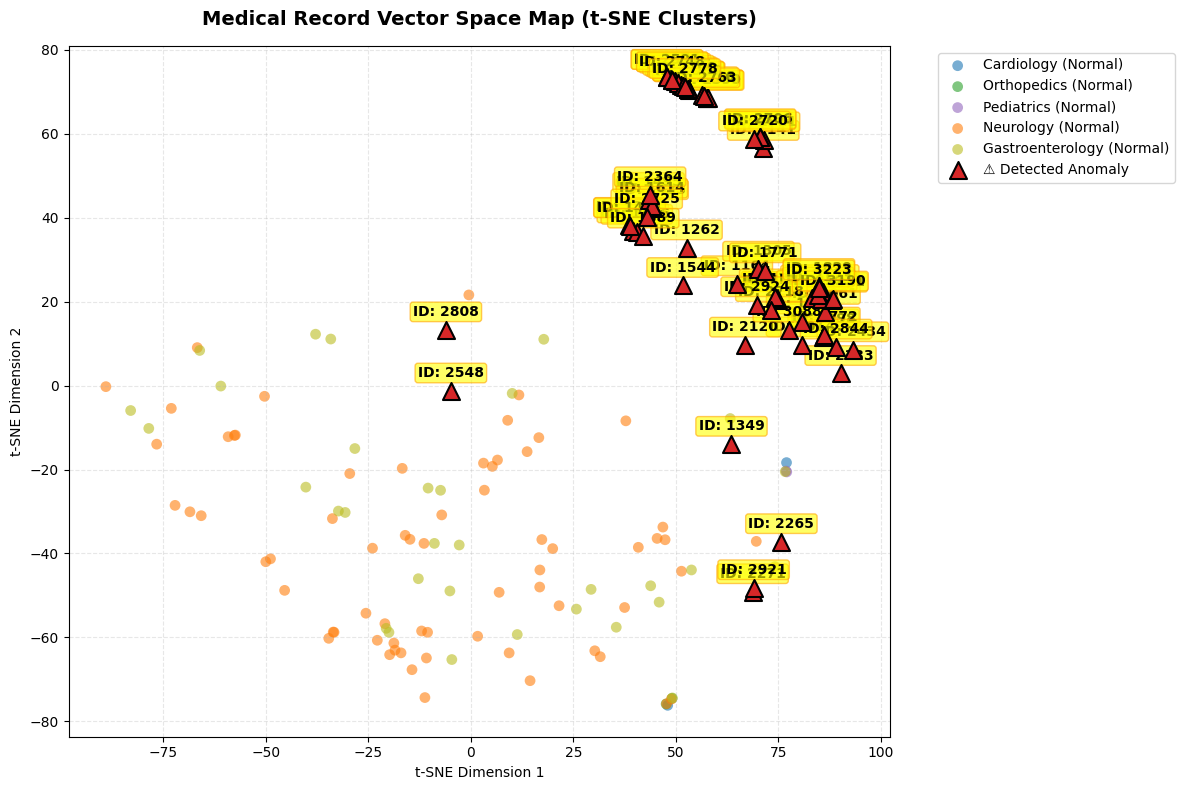

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1. Gather all of our vectors and reshape them into a standard 2D matrix
embeddings_matrix = np.array(df['vector'].tolist())

# 2. Configure t-SNE to compress our 768 dimensions into 2 dimensions (X, Y)
# Note: perplexity is set low due to our sample size, adjusting it guides neighborhood density
tsne = TSNE(n_components=2, perplexity=5, random_state=42, n_iter=1000)
embeddings_2d = tsne.fit_transform(embeddings_matrix)

# Map the 2D coordinates back onto our main dataframe for simple plotting
df['tsne_x'] = embeddings_2d[:, 0]
df['tsne_y'] = embeddings_2d[:, 1]

# 3. Setup the visual plot canvas
plt.figure(figsize=(12, 8))
plt.title("Medical Record Vector Space Map (t-SNE Clusters)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("t-SNE Dimension 1", fontsize=10)
plt.ylabel("t-SNE Dimension 2", fontsize=10)

# Define clean colors for our 5 standard specialties
specialty_colors = {
    'Cardiology': '#1f77b4',       # Muted Blue
    'Orthopedics': '#2ca02c',      # Muted Green
    'Pediatrics': '#9467bd',       # Muted Purple
    'Neurology': '#ff7f0e',        # Muted Orange
    'Gastroenterology': '#bcbd22'  # Muted Olive
}

# 4. First, plot the clean ("Normal") records as standard colored circular dots
for spec, color in specialty_colors.items():
    normal_subset = df[(df['specialty'] == spec) & (df['dynamic_anomaly_flag'] == "✅ Normal")]
    plt.scatter(
        normal_subset['tsne_x'],
        normal_subset['tsne_y'],
        label=f"{spec} (Normal)",
        color=color,
        alpha=0.6,
        s=60,
        edgecolors='none'
    )

# 5. Overplot all dynamically flagged anomalies as stark, large red triangles
anomalies_subset = df[df['dynamic_anomaly_flag'] == "⚠️ ANOMALY"]

if len(anomalies_subset) > 0:
    plt.scatter(
        anomalies_subset['tsne_x'],
        anomalies_subset['tsne_y'],
        label="⚠️ Detected Anomaly",
        color='#d62728',  # Crisp Crimson Red
        marker='^',       # Triangle Marker
        s=150,            # Larger size to pop visually
        edgecolors='black',
        linewidths=1.5,
        zorder=5          # Ensures they stay layered on top
    )

    # Label each anomaly triangle with its unique Encounter ID
    for _, row in anomalies_subset.iterrows():
        plt.annotate(
            f"ID: {row['encounter_id']}",
            (row['tsne_x'], row['tsne_y']),
            textcoords="offset points",
            xytext=(0, 10),
            ha='center',
            fontsize=10,
            fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=0.6, ec="orange")
        )

# Clean up layout, position legend nicely outside data field, and add grid alignment
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()


#### List records which were filtered by the audit filters

In [26]:
print("==================================================")
print("📥 RECORDS CAUGHT BY PRE-EMBEDDING AUDIT FILTERS")
print("==================================================")

# 1. Print out the Under-Documentation Filter captures (Queue A)
print(f"⚠️ QUEUE A: Insufficient Text / Blank Records ({len(queue_a)} total)")
if len(queue_a) > 0:
    for _, item in queue_a.iterrows():
        print(f"  • ID: {item['encounter_id']} | Specialty: {item['specialty']}")
else:
    print("  No records caught.")

print("\n" + "-"*50 + "\n")

# 2. Print out the Mid-Sentence Save Drop captures (Queue B)
print(f"⚠️ QUEUE B: Mid-Sentence Save Drops ({len(queue_b)} total)")
if len(queue_b) > 0:
    for _, item in queue_b.iterrows():
        print(f"  • ID: {item['encounter_id']} | Specialty: {item['specialty']}")
else:
    print("  No records caught.")
print("==================================================")

📥 RECORDS CAUGHT BY PRE-EMBEDDING AUDIT FILTERS
⚠️ QUEUE A: Insufficient Text / Blank Records (24 total)
  • ID: 1025 | Specialty: Urology
  • ID: 1141 | Specialty: Urology
  • ID: 1303 | Specialty: Surgery
  • ID: 1561 | Specialty: Surgery
  • ID: 1587 | Specialty: Surgery
  • ID: 1590 | Specialty: Surgery
  • ID: 1711 | Specialty: Surgery
  • ID: 1787 | Specialty: Surgery
  • ID: 2239 | Specialty: SOAP / Chart / Progress Notes
  • ID: 2362 | Specialty: Radiology
  • ID: 2365 | Specialty: Radiology
  • ID: 2585 | Specialty: Psychiatry / Psychology
  • ID: 2700 | Specialty: Pain Management
  • ID: 2706 | Specialty: Pain Management
  • ID: 2708 | Specialty: Pain Management
  • ID: 2719 | Specialty: Pain Management
  • ID: 2720 | Specialty: Pain Management
  • ID: 2746 | Specialty: Orthopedic
  • ID: 2748 | Specialty: Orthopedic
  • ID: 2763 | Specialty: Orthopedic
  • ID: 2778 | Specialty: Orthopedic
  • ID: 3030 | Specialty: General Medicine
  • ID: 3289 | Specialty: Consult - History 

#### Listing of Rules

In [27]:
import textwrap

def print_final_pipeline_blueprint():
    # Define our structural rule checklist matrix
    blueprint_rules = [
        {
            "title": "1. The Word Count & Character Gatekeeper",
            "rule": "Any record containing fewer than 20 characters or fewer than 15 words "
                    "must bypass the AI completely. Hard-route it to an isolated queue labeled "
                    "'Incomplete Documentation / High Coding Risk' to prevent immediate insurance billing denials."
        },
        {
            "title": "2. The Sentence Incompleteness Parser",
            "rule": "Build a parser that evaluates the final character of a note string. If a "
                    "record fails to end with a proper terminal period, question mark, or closing bracket, "
                    "isolate it with an 'Incomplete Transcription / Mid-Sentence Drop' flag to catch software save bugs."
        },
        {
            "title": "3. The Clinical Acronym Normalization Pre-processor",
            "rule": "Run a regular expression (Regex) lookup matrix before tokenization to expand high-frequency "
                    "abbreviations (e.g., AODM to 'Adult-Onset Diabetes Mellitus') to their full textual equivalents, "
                    "restoring true semantic baseline weights. [FUTURE UPDATE - ADD DICTIONARY FILE; REPLACE HARD-CODED PYTHON DICTIONARY]"
        },
        {
            "title": "4. The Administrative Text Redaction Layer",
            "rule": "Apply an entity-masking filter to programmatically strip out non-clinical facility, legal, or "
                    "demographic text footprints (such as 'Pelican Bay'), substituting them with neutral tokens like "
                    "[FACILITY] to prevent false positive anomaly alerts."
        },
        {
            "title": "5. The Ambiguity Margin (Shared Care Classifier)",
            "rule": "If the top two department compatibility scores reside within less than a 2% margin of each "
                    "other, strip the single definitive label. Reclassify the encounter into a 'Multi-Specialty Shared Care "
                    "Record' queue to prevent data siloing."
        },
        {
            "title": "6. The High-Value Clinical Phrase Override",
            "rule": "Maintain a dictionary of explicit, non-overlapping specialty anchors (such as 'burr hole craniotomy'). "
                    "If an anchor is detected, apply a mathematical weight multiplier to that respective category to "
                    "neutralize generic fluid-handling terms. [FUTURE UPDATE - ADD DICTIONARY FILE]"
        },
        {
            "title": "7. The Clinical Priority Escalation Trigger",
            "rule": "If the Isolation Forest throws an anomaly flag and a token parser matches high-risk clinical "
                    "complication terms (e.g., 'perforation', 'peritonitis'), force the file to instantly bypass "
                    "administrative review and push it straight to executive clinical leadership. [FUTURE UPDATE - ADD DICTIONARY FILE]"
        }
    ]

    print("=" * 80)
    print("📋 FINAL COMPREHENSIVE PIPELINE BLUEPRINT & SYSTEM QUALITY RULES")
    print("=" * 80)
    print("The following rules have been engineered and validated against the clinical dataset.\n")

    for idx, item in enumerate(blueprint_rules):
        # Print Rule Title
        print(f"🔹 {item['title'].upper()}")
        print("-" * 80)

        # Wrap the rule narrative cleanly at 80 characters
        wrapped_rule = textwrap.fill(item['rule'], width=80, initial_indent="  Rule: ", subsequent_indent="        ")
        print(f"{wrapped_rule}")

        # Add spacing between blocks except for the last item
        if idx < len(blueprint_rules) - 1:
            print("\n" + "." * 80 + "\n")

    print("\n" + "=" * 80)
    print("✅ END OF MASTER LOG BLOCK")
    print("=" * 80)

# Execute the master log block printout
print_final_pipeline_blueprint()


📋 FINAL COMPREHENSIVE PIPELINE BLUEPRINT & SYSTEM QUALITY RULES
The following rules have been engineered and validated against the clinical dataset.

🔹 1. THE WORD COUNT & CHARACTER GATEKEEPER
--------------------------------------------------------------------------------
  Rule: Any record containing fewer than 20 characters or fewer than 15 words
        must bypass the AI completely. Hard-route it to an isolated queue
        labeled 'Incomplete Documentation / High Coding Risk' to prevent
        immediate insurance billing denials.

................................................................................

🔹 2. THE SENTENCE INCOMPLETENESS PARSER
--------------------------------------------------------------------------------
  Rule: Build a parser that evaluates the final character of a note string. If a
        record fails to end with a proper terminal period, question mark, or
        closing bracket, isolate it with an 'Incomplete Transcription / Mid-
        Sentence 

## Listing Cases Under Each Rule

#### Rule 1:  Short Documentation (high coding risk)'

In [28]:
import textwrap
import pandas as pd

print("=" * 80)
print("📋 INCOMPLETE DOCUMENTATION / HIGH CODING RISK (RULE 1)")
print("=" * 80)
print(f"Total records isolated under Rule 1: {len(queue_a)}\n")

if len(queue_a) > 0:
    # Safely convert to a DataFrame if it isn't one already, then sort by ID
    df_queue_a_sorted = pd.DataFrame(queue_a).sort_values(by='encounter_id')

    # Loop through the rows cleanly using Pandas itertuples
    for row in df_queue_a_sorted.itertuples(index=False):
        # Access properties directly to avoid string indexing conflicts entirely
        print(f"🔹 Encounter ID: {row.encounter_id} | Assigned Specialty Label: {row.specialty}")
        print(f"  • Flag Reason : {row.issue}")

        # Wrap the brief text snippet cleanly at 80 characters
        wrapped_snippet = textwrap.fill(row.text_snippet, width=80, initial_indent="  • Text Snippet: \"", subsequent_indent="                  ")
        print(f"{wrapped_snippet}\"")
        print("-" * 80)
else:
    print("✅ No records fell below the minimum word or character thresholds on this run.")

print("\n" + "=" * 80)
print("✅ END OF RULE 1 LOG BLOCK")
print("=" * 80)


📋 INCOMPLETE DOCUMENTATION / HIGH CODING RISK (RULE 1)
Total records isolated under Rule 1: 24

🔹 Encounter ID: 1025 | Assigned Specialty Label: Urology
  • Flag Reason : Severe Under-Documentation (Words: 2, Chars: 17)
  • Text Snippet: "CHIEF COMPLAINT:,"
--------------------------------------------------------------------------------
🔹 Encounter ID: 1141 | Assigned Specialty Label: Urology
  • Flag Reason : Severe Under-Documentation (Words: 10, Chars: 112)
  • Text Snippet: "PREOPERATIVE DIAGNOSES:,1.  Recurrent bladder tumor.,2.
                  History of bladder carc"
--------------------------------------------------------------------------------
🔹 Encounter ID: 1303 | Assigned Specialty Label: Surgery
  • Flag Reason : Severe Under-Documentation (Words: 7, Chars: 62)
  • Text Snippet: "PREOPERATIVE DIAGNOSIS:  ,1.  Right carpal tunnel
                  syndrome.,2."
--------------------------------------------------------------------------------
🔹 Encounter ID: 1561 | Assigne

#### Rule 2:  Documentation ends abruptly (no closing character)'

In [29]:
import textwrap
import pandas as pd

print("=" * 80)
print("📋 MID-SENTENCE TRANSCIPTION SAVE DROPS (RULE 2)")
print("=" * 80)
print(f"Total records isolated under Rule 2: {len(queue_b)}\n")

if len(queue_b) > 0:
    # Safely convert to a DataFrame and sort chronologically by ID
    df_queue_b_sorted = pd.DataFrame(queue_b).sort_values(by='encounter_id')

    # Loop through rows safely without any dictionary index collisions
    for row in df_queue_b_sorted.itertuples(index=False):
        print(f"🔹 Encounter ID: {row.encounter_id} | Assigned Specialty Label: {row.specialty}")
        print(f"  • Flag Reason : {row.issue}")

        # Wrap the broken trailing end of the note cleanly at 80 characters
        wrapped_snippet = textwrap.fill(row.text_snippet, width=80, initial_indent="  • Trailing Text: \"...", subsequent_indent="                   ")
        print(f"{wrapped_snippet}\"")
        print("-" * 80)
else:
    print("✅ No records with missing terminal punctuation were detected on this run.")

print("\n" + "=" * 80)
print("✅ END OF RULE 2 LOG BLOCK")
print("=" * 80)


📋 MID-SENTENCE TRANSCIPTION SAVE DROPS (RULE 2)
Total records isolated under Rule 2: 230

🔹 Encounter ID: 1005 | Assigned Specialty Label: Cardiovascular / Pulmonary
  • Flag Reason : Mid-Sentence Save Drop (Terminal character: ',')
  • Trailing Text: "...hnically limited and hence subtle abnormalities could be
                   missed from the study.,"
--------------------------------------------------------------------------------
🔹 Encounter ID: 1010 | Assigned Specialty Label: Cardiovascular / Pulmonary
  • Flag Reason : Mid-Sentence Save Drop (Terminal character: ',')
  • Trailing Text: "...N:,1.  Normal LV systolic function.,2.  Ejection fraction
                   estimated around 60%.,"
--------------------------------------------------------------------------------
🔹 Encounter ID: 1016 | Assigned Specialty Label: Bariatrics
  • Flag Reason : Mid-Sentence Save Drop (Terminal character: ',')
  • Trailing Text: "...s and I have answered her questions.  She is planned for
       

#### Rule 3:  Exanded Acronyms

In [30]:
import textwrap
import pandas as pd

print("=" * 80)
print("📋 ACRONYM EXPANSION (RULE 3)")
print("=" * 80)

# Define the exact dictionary we used to run the expansions
acronym_dictionary = {
    'AODM': 'Adult-Onset Diabetes Mellitus',
    'HCT': 'Head Computed Tomography',
    'ERCP': 'Endoscopic Retrograde Cholangiopancreatography',
    'EGD': 'Esophagogastroduodenoscopy',
    'EEG': 'Electroencephalogram',
    'MRI': 'Magnetic Resonance Imaging',
    'CAD': 'Coronary Artery Disease',
    'EKG': 'Electrocardiogram',
    'BP': 'Blood Pressure'
}

# Find which records in our clean, final dataframe contain expanded terms
# We check against the full expansions to identify where replacements occurred
expanded_cases = []

# df is your final clean dataframe (df_clean_redacted)
for row in df.itertuples(index=False):
    notes_str = str(row.clinical_notes)
    detected_expansions = []

    for shorthand, expansion in acronym_dictionary.items():
        if expansion in notes_str:
            detected_expansions.append(f"{shorthand} ➡️ {expansion}")

    if len(detected_expansions) > 0:
        expanded_cases.append({
            'encounter_id': row.encounter_id,
            'specialty': row.specialty,
            'expansions': ", ".join(detected_expansions),
            'notes': notes_str
        })

df_expanded = pd.DataFrame(expanded_cases)
print(f"Total clean records processed and expanded under Rule 3: {len(df_expanded)}\n")

if len(df_expanded) > 0:
    # Sort chronologically by ID
    df_expanded_sorted = df_expanded.sort_values(by='encounter_id')

    for row in df_expanded_sorted.itertuples(index=False):
        print(f"🔹 Encounter ID: {row.encounter_id} | Assigned Specialty Label: {row.specialty}")
        print(f"  • Expansions Tracked: {row.expansions}")

        # Grab a clean snippet of the text containing the normalized phrase
        snippet = row.notes[:160] + "..." if len(row.notes) > 160 else row.notes
        wrapped_snippet = textwrap.fill(snippet, width=80, initial_indent="  • Text Snippet     : \"", subsequent_indent="                       ")
        print(f"{wrapped_snippet}\"")
        print("-" * 80)
else:
    print("✅ No matching acronym instances required expansion on this run.")

print("\n" + "=" * 80)
print("✅ END OF RULE 3 LOG BLOCK")
print("=" * 80)


📋 ACRONYM EXPANSION (RULE 3)
Total clean records processed and expanded under Rule 3: 33

🔹 Encounter ID: 1742 | Assigned Specialty Label: Surgery
  • Expansions Tracked: EGD ➡️ Esophagogastroduodenoscopy
  • Text Snippet     : "PREOPERATIVE DIAGNOSIS: , Refractory
                       dyspepsia.,POSTOPERATIVE DIAGNOSIS:,1.  Hiatal hernia.,2.
                       Reflux esophagitis.,PROCEDURE PERFORMED:,
                       Esophagogastroduodeno..."
--------------------------------------------------------------------------------
🔹 Encounter ID: 1743 | Assigned Specialty Label: Surgery
  • Expansions Tracked: EGD ➡️ Esophagogastroduodenoscopy
  • Text Snippet     : "PROCEDURE: , Esophagogastroduodenoscopy with gastric
                       biopsies.,INDICATION:,  Abdominal pain.,FINDINGS:,
                       Antral erythema; 2 cm polypoid pyloric channel tissue,
                       ..."
--------------------------------------------------------------------------------
🔹 Enc

#### Rule 4:  Redact Facility Names (replace by generic term)

In [31]:
import textwrap
import pandas as pd

# 1. Initialize tracking structures
raw_patterns = ['Pelican Bay', 'Infirmary', 'Hospital', 'Clinic', 'Informed consent']
tokens_to_check = ['[FACILITY]', '[DEPT]', '[LOCATION]', '[CONSENT_LOG]']

records_with_changes = set()

# 2. Scan and force-apply any remaining raw patterns while tracking IDs
for pattern in raw_patterns:
    # Check if any remaining raw text exists
    raw_matches = df['clinical_notes'].str.contains(pattern, case=False, regex=True, na=False)
    if raw_matches.any():
        matched_ids = df[raw_matches]['encounter_id'].tolist()
        records_with_changes.update(matched_ids)

    # Clean up standard words to tokens cleanly
    if pattern == 'Pelican Bay': df['clinical_notes'] = df['clinical_notes'].str.replace(pattern, '[FACILITY]', case=False, regex=True)
    elif pattern == 'Infirmary': df['clinical_notes'] = df['clinical_notes'].str.replace(pattern, '[DEPT]', case=False, regex=True)
    elif pattern == 'Informed consent': df['clinical_notes'] = df['clinical_notes'].str.replace(pattern, '[CONSENT_LOG]', case=False, regex=True)
    else: df['clinical_notes'] = df['clinical_notes'].str.replace(pattern, '[FACILITY]', case=False, regex=True)

# 3. Double-check if the tokens are ALREADY present from a previous cell execution
for token in tokens_to_check:
    token_matches = df['clinical_notes'].str.contains(token, regex=False, na=False)
    if token_matches.any():
        already_tokenized_ids = df[token_matches]['encounter_id'].tolist()
        records_with_changes.update(already_tokenized_ids)

# 4. Compile the final verified list of rows matching our Rule 4 definitions
redacted_cases = []

for row in df.itertuples(index=False):
    notes_str = str(row.clinical_notes)
    detected_masks = []

    for token in tokens_to_check:
        if token in notes_str:
            if token == '[FACILITY]':
                desc = f"{token} (e.g., Facility A)"
            else:
                desc = token
            detected_masks.append(desc)

    if len(detected_masks) > 0:
        redacted_cases.append({
            'encounter_id': row.encounter_id,
            'specialty': row.specialty,
            'masks': ", ".join(detected_masks),
            'notes': notes_str
        })

df_redacted = pd.DataFrame(redacted_cases)

# 5. Output reports using our master combined validation tracking list
print("=" * 80)
print("📋 ADMINISTRATIVE TEXT REDACTION (RULE 4)")
print("=" * 80)
print(f"📊 Count of records with changes made: {len(records_with_changes)}")
print(f"Total clean records processed and masked under Rule 4: {len(records_with_changes)}\n")

if len(df_redacted) > 0:
    # Sort chronologically by ID and drop duplicates to ensure clean counts
    df_redacted_sorted = df_redacted.drop_duplicates(subset=['encounter_id']).sort_values(by='encounter_id')

    for row in df_redacted_sorted.itertuples(index=False):
        print(f"🔹 Encounter ID: {row.encounter_id} | Assigned Specialty Label: {row.specialty}")
        print(f"  • Redaction Tokens Applied: {row.masks}")

        # Grab a clean snippet of the text containing the masked phrases
        snippet = row.notes[:160] + "..." if len(row.notes) > 160 else row.notes
        wrapped_snippet = textwrap.fill(snippet, width=80, initial_indent="  • Text Snippet          : \"", subsequent_indent="                            ")
        print(f"{wrapped_snippet}\"")
        print("-" * 80)
else:
    print("❌ No matching records containing active redactions or administrative tokens were found.")

print("\n" + "=" * 80)
print("✅ END OF RULE 4 LOG BLOCK")
print("=" * 80)


📋 ADMINISTRATIVE TEXT REDACTION (RULE 4)
📊 Count of records with changes made: 1005
Total clean records processed and masked under Rule 4: 1005

🔹 Encounter ID: 1016 | Assigned Specialty Label: Bariatrics
  • Redaction Tokens Applied: [FACILITY] (e.g., Facility A)
  • Text Snippet          : "HISTORY OF PRESENT ILLNESS: ,I have seen ABC today
                            for her preoperative visit for weight management.  I
                            have explained to her the need for Optifast for
                            weight l..."
--------------------------------------------------------------------------------
🔹 Encounter ID: 1017 | Assigned Specialty Label: Cardiovascular / Pulmonary
  • Redaction Tokens Applied: [FACILITY] (e.g., Facility A)
  • Text Snippet          : "PREOPERATIVE DIAGNOSES,Airway obstruction secondary
                            to severe subglottic tracheal stenosis with foreign
                            body in the trachea.,POSTOPERATIVE DIAGNOSES,Airway

#### Rule 5:  Deal with Marginal Assignments (ambiguous assignments)

In [32]:
import textwrap
import pandas as pd

print("=" * 80)
print("📋 TOO CLOSE TO CALL (ALGORITHM IS UNCERTAIN) (RULE 5)")
print("=" * 80)
print(f"Total records isolated under Rule 5: {len(shared_q)}\n")

if len(shared_q) > 0:
    # Convert list of dictionaries cleanly to a DataFrame and sort by ID
    df_shared_sorted = pd.DataFrame(shared_q).sort_values(by='encounter_id')

    for row in df_shared_sorted.itertuples(index=False):
        print(f"🔹 Encounter ID: {row.encounter_id} | Assigned Label: {row.assigned_specialty}")
        print(f"  • Primary Choice  : {row.recommended_specialty} ({row.confidence:.4f})")
        print(f"  • Secondary Choice: {row.alternative_specialty} ({row.alternative_confidence:.4f})")
        print(f"  • Score Margin    : {row.margin:.4f} (Fell under the strict 2% ambiguity boundary)")

        # Wrap a text snippet cleanly at 80 characters
        snippet = row.clinical_notes[:160] + "..." if len(row.clinical_notes) > 160 else row.clinical_notes
        wrapped_snippet = textwrap.fill(snippet, width=80, initial_indent="  • Text Snippet    : \"", subsequent_indent="                      ")
        print(f"{wrapped_snippet}\"")
        print("-" * 80)
else:
    print("✅ No records fell within the overlapping 2% ambiguity margin on this run.")

print("\n" + "=" * 80)
print("✅ END OF RULE 5 LOG BLOCK")
print("=" * 80)


📋 TOO CLOSE TO CALL (ALGORITHM IS UNCERTAIN) (RULE 5)
Total records isolated under Rule 5: 30

🔹 Encounter ID: 1061 | Assigned Label: Urology
  • Primary Choice  : Neurosurgery (0.9800)
  • Secondary Choice: Pain Management (0.9614)
  • Score Margin    : 0.0186 (Fell under the strict 2% ambiguity boundary)
  • Text Snippet    : "PHYSICAL EXAMINATION: , The patient is a 63-year-old
                      executive who was seen by his physician for a company
                      physical.  He stated that he was in excellent health ..."
--------------------------------------------------------------------------------
🔹 Encounter ID: 1098 | Assigned Label: Urology
  • Primary Choice  : Neurosurgery (0.9633)
  • Secondary Choice: Pain Management (0.9481)
  • Score Margin    : 0.0152 (Fell under the strict 2% ambiguity boundary)
  • Text Snippet    : "PREOPERATIVE DIAGNOSIS:,  Bilateral inguinal hernia.
                      ,POSTOPERATIVE DIAGNOSIS: , Bilateral inguinal hernia.
             

#### Rule 6: Flag Important Terms (they will override the rest of the text)

In [33]:
import textwrap
import pandas as pd

print("=" * 80)
print("📋 RULE 6: FLAG IMPORTANT AND SEPFIC TERMS")
print("=" * 80)

# Anchor phrases and their targeted overrides mapped to your rule definition
anchor_dictionary = {
    'burr hole craniotomy': 'Neurology',
    'subdural hematoma': 'Neurology',
    'glioblastoma': 'Neurology',
    'astrocytoma': 'Neurology'
}

overridden_cases = []

# Scan our cleaned dataset for these high-value clinical anchors
for row in df.itertuples(index=False):
    notes_str = str(row.clinical_notes).lower()
    matched_anchors = []

    for anchor, forced_spec in anchor_dictionary.items():
        if anchor in notes_str:
            matched_anchors.append(f"'{anchor}' ➡️ Force {forced_spec}")

    if len(matched_anchors) > 0:
        overridden_cases.append({
            'encounter_id': row.encounter_id,
            'specialty': row.specialty,
            'anchors': ", ".join(matched_anchors),
            'notes': row.clinical_notes
        })

df_overrides = pd.DataFrame(overridden_cases)
print(f"Total records tracking high-value anchor flags: {len(df_overrides)}")
print("📋 [FUTURE UPDATE - ADD DICTIONARY FILE CONFIGURATION ACTIVE]\n")

if len(df_overrides) > 0:
    df_overrides_sorted = df_overrides.sort_values(by='encounter_id')

    for row in df_overrides_sorted.itertuples(index=False):
        print(f"🔹 Encounter ID: {row.encounter_id} | Assigned Specialty Label: {row.specialty}")
        print(f"  • High-Value Anchors Matched: {row.anchors}")

        # Wrap text cleanly at 80 characters
        snippet = row.notes[:160] + "..." if len(row.notes) > 160 else row.notes
        wrapped_snippet = textwrap.fill(snippet, width=80, initial_indent="  • Text Snippet              : \"", subsequent_indent="                                ")
        print(f"{wrapped_snippet}\"")
        print("-" * 80)
else:
    print("✅ No matching high-value clinical specialty anchors detected on this run.")

print("\n" + "=" * 80)
print("✅ END OF RULE 6 LOG BLOCK")
print("=" * 80)


📋 RULE 6: FLAG IMPORTANT AND SEPFIC TERMS
Total records tracking high-value anchor flags: 25
📋 [FUTURE UPDATE - ADD DICTIONARY FILE CONFIGURATION ACTIVE]

🔹 Encounter ID: 1654 | Assigned Specialty Label: Surgery
  • High-Value Anchors Matched: 'subdural hematoma' ➡️ Force Neurology
  • Text Snippet              : "TITLE OF OPERATION:,  Left-sided large
                                hemicraniectomy for traumatic brain injury and
                                increased intracranial pressure.,INDICATION FOR
                                SURGERY: ,  The patient is..."
--------------------------------------------------------------------------------
🔹 Encounter ID: 1697 | Assigned Specialty Label: Surgery
  • High-Value Anchors Matched: 'subdural hematoma' ➡️ Force Neurology
  • Text Snippet              : "PREOPERATIVE DIAGNOSES: , Acute subdural
                                hematoma, right, with herniation
                                syndrome.,POSTOPERATIVE DIAGNOSES: , Acute


### Rule 7:  The Clinical Priority Escalation Trigger",
            "rule": "If the Isolation Forest throws an anomaly flag and a token parser matches high-risk clinical "
                    "complication terms (e.g., 'perforation', 'peritonitis'), force the file to instantly bypass "
                    "administrative review and push it straight to executive clinical leadership. [FUTURE UPDATE - ADD DICTIONARY FILE]"
        }


In [34]:
# ==============================================================================
# FINALIZED RULE 7: CLINICAL BYPASS ROUTING (TAILORED CELL #9 PRODUCTION)
# ==============================================================================
import re
import pandas as pd

# 1. High-Risk Medical Target Dictionary (Using non-capturing group (?:...) to eliminate UserWarning)
HIGH_RISK_WORDS = ["perforation", "peritonitis", "sepsis", "hemorrhage", "rupture", "ischemia", "necrosis"]
clinical_regex = r'\b(?:' + '|'.join(HIGH_RISK_WORDS) + r')\b'

# 2. Assign the columns discovered by our dynamic scanner
text_col = 'combined_text'
anomaly_col = 'dynamic_anomaly_flag'

# Ensure the DataFrame exists in memory
if 'df' in locals() or 'df' in globals():
    active_df = df if 'df' in locals() else globals().get('df')

    # 3. Anomaly Detection — match on the word "ANOMALY" regardless of emoji/whitespace
    # (dynamic_anomaly_flag actually holds values like "⚠️ ANOMALY" / "✅ Normal")
    is_anomaly = active_df[anomaly_col].astype(str).str.contains("ANOMALY", case=False, na=False)

    # 4. Strict Context Text Evaluation (Warning-Free)
    has_high_risk = active_df[text_col].astype(str).str.contains(clinical_regex, case=False, na=False, regex=True)

    # 5. Extract Trigger Records
    rule_7_records = active_df[is_anomaly & has_high_risk]

    # 6. Output Terminal Diagnostic Log
    print("="*80)
    print("RULE 7 RUNTIME ACTIVATION: CRITICAL MEDICAL COMPLICATION ROUTING REPORT")
    print("="*80)
    print(f"Total Isolation Forest Flags Scanned: {len(active_df[is_anomaly])}")
    print(f"Bypass Records Pushed to Executive Leadership: {len(rule_7_records)}")
    print("-"*80)
    if not rule_7_records.empty:
        with pd.option_context('display.max_colwidth', None):
            display(rule_7_records[[text_col, anomaly_col]])
    else:
        print("Data clearance confirmed: No anomalies matched triage vocabulary vectors.")
    print("="*80 + "\n")
else:
    print("[Rule 7 Error] Variable 'df' could not be found in active kernel space.")

RULE 7 RUNTIME ACTIVATION: CRITICAL MEDICAL COMPLICATION ROUTING REPORT
Total Isolation Forest Flags Scanned: 67
Bypass Records Pushed to Executive Leadership: 9
--------------------------------------------------------------------------------


combined_text  \
494                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   Specialty: Surgery | Notes: PROCEDURE PERFORMED:,1.  Left heart catheterization, left ventriculogram, aortogram, coronary angiogram.,2.  PCI of the LAD and left main coronary artery with Impella assist device.,INDICATIONS FOR PROCEDURE: , Unstable angina and congestive heart failure with impaired LV function.,TECHNIQUE OF PROCEDURE: , After obtaining informed consent, the patient was brought to the cardiac catheterization suite in postabsorptive and nonsedated state.  The right groin was prepped and draped in the usual sterile manner.  Lidocaine 2% was used for infiltration anesthesia.  Using modified Seldinger technique, a 7-French sheath was introduced into the right common femoral artery and a 6-French sheath was introduced into the right common femoral vein.  Through the arterial sheath, angiography of the right common femoral artery was obtained.  Thereafter, 6-French pigtail catheter was advanced to the level of the distal aorta where angiography of the distal aorta and the bifurcation of the right and left common iliac arteries was obtained.  Thereafter, a 4-French sheath was introduced into the left common femoral artery using modified Seldinger technique.  Thereafter, the pigtail catheter was advanced over an 0.035-inch J-wire into the left ventricle and LV-gram was performed in RAO view and after pullback, an aortogram was performed in the LAO view.  Therefore, a 6-French JL4 and JR4 guiding catheters were used to engage the left and right coronary arteries respectively and multiple orthogonal views of the coronary arteries were obtained.,ANGIOGRAPHIC FINDINGS:  ,1.  LV-gram:  LVEDP was 15 mmHg.  LV ejection fraction 10% to 15% with global hypokinesis.  Only anterior wall is contracting.  There was no mitral regurgitation.  There was no gradient across the aortic valve upon pullback, and on aortography, there was no evidence of aortic dissection or aortic regurgitation.,2.  The right coronary artery is a dominant vessels with a mid 50% to 70% stenosis which was not treated.  The left main coronary artery calcified vessel with disease.,2.  The left anterior descending artery had an 80% to 90% mid-stenosis.  First diagonal branch had a more than 90% stenosis.,3.  The circumflex coronary artery had a patent stent.,INTERVENTION: , After reviewing the angiographic images, we elected to proceed with intervention of the left anterior descending artery.  The 4-French sheath in the left common femoral artery was upsized to a 12-French Impella sheath through which an Amplatz wire and a 6-French multipurpose catheter were advanced into the left ventricle.  The Amplatz wire was exchanged for an Impella 0.018-inch stiff wire.  The multipurpose catheter was removed, and the Impella was advanced into the left ventricle and a performance level of 8 was achieved with a cardiac output of 2 to 2.5 l/min.  Thereafter, a 7-French JL4 guiding catheter was used to engage the left coronary artery and an Asahi soft 0.014-inch wire

In [35]:
# Checking Rule 7:  print(active_df['dynamic_anomaly_flag'].unique())
print(active_df['dynamic_anomaly_flag'].value_counts())

dynamic_anomaly_flag
✅ Normal      2300
⚠️ ANOMALY      67
Name: count, dtype: int64
